# 36 — Vision Transformer Intuition

A Vision Transformer (ViT) converts an image into a sequence of patch tokens and processes that sequence with Transformer encoder blocks. This notebook develops the representation and forward pass without training a full image model yet.

## Learning objectives

- calculate how image and patch sizes determine sequence length;
- convert channel-first images into non-overlapping flattened patches;
- reconstruct and visualize the patch layout;
- project raw patches into model-width tokens;
- prepend a classification token and add positional information;
- assemble a small ViT forward pass and map attention back to image space.


In [65]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.positional_encoding import add_positional_encoding
from cs231n_practice.transformer import transformer_encoder_block_forward

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)


## 1. From spatial grid to token sequence

For an image with height $H$, width $W$, and square non-overlapping patches of size $P$, the patch grid and number of tokens are

$$
H_p=H/P, \qquad W_p=W/P, \qquad L_p=H_pW_p.
$$

Each patch contains $C P^2$ scalar pixel values. After flattening, a batch therefore changes shape as follows:

```text
images:   (N, C, H, W)
patches:  (N, L_p, C * P * P)
```

A classification token later increases the Transformer sequence length from $L_p$ to $L_p+1$. Smaller patches preserve finer spatial detail but create a longer sequence and a larger quadratic attention matrix.

### Exercise 1 — Calculate patch sequence lengths


In [66]:
image_height = image_width = 32
channels = 3
patch_sizes = [4, 8, 16]

for patch_size in patch_sizes:
    # calculate grid_size, num_patches, patch_dim, and the score
    # matrix size after adding one CLS token.
    grid_size = image_height // patch_size
    num_patches = grid_size ** 2
    patch_dim = channels * patch_size ** 2
    sequence_length = num_patches + 1 # +1 for CLS token
    attention_entries = sequence_length**2
    print(
        f"P={patch_size:2d}: grid={grid_size}x{grid_size}, ",
        f"patches={num_patches:2d}, patch_dim={patch_dim:3d}, ",
        f"attention entries/head={attention_entries:4d}",
    )


P= 4: grid=8x8,  patches=64, patch_dim= 48,  attention entries/head=4225
P= 8: grid=4x4,  patches=16, patch_dim=192,  attention entries/head= 289
P=16: grid=2x2,  patches= 4, patch_dim=768,  attention entries/head=  25


## 2. Patchify an image

Patchification can be implemented entirely with reshape and transpose. First expose separate grid and within-patch axes:

```text
(N, C, H, W)
-> (N, C, H_p, P, W_p, P)
-> (N, H_p, W_p, C, P, P)
-> (N, H_p * W_p, C * P * P)
```

The transpose puts the two grid axes next to each other, preserving row-major patch order: left to right, then top to bottom. No information is discarded; only the organization changes.

### Exercise 2 — Implement non-overlapping patchification


In [67]:
def image_to_patches(images, patch_size):
    """Convert (N, C, H, W) images to flattened patch sequences."""
    # TODO: validate rank, positive patch size, and exact divisibility.
    assert images.ndim == 4, "images must have rank 4"
    assert patch_size > 0, "patch_size must be positive"
    assert images.shape[2] % patch_size == 0, "image height must be divisible by patch_size"
    assert images.shape[3] % patch_size == 0, "image width must be divisible by patch_size"
    # reshape, transpose, and flatten the patch axes.
    N, C, H, W = images.shape
    grid_H = H // patch_size
    grid_W = W // patch_size
    images_reshaped = images.reshape(
        N, C, grid_H, patch_size, grid_W, patch_size,
    )
    images_transposed = images_reshaped.transpose(0, 2, 4, 1, 3, 5)
    patches = images_transposed.reshape(
        N, grid_H * grid_W, C * patch_size * patch_size,
    )
    return patches


# A reproducible 16x16 RGB image with visibly different regions.
image = np.zeros((3, 16, 16), dtype=np.float64)
image[0, :8, :8] = 1.0
image[1, :8, 8:] = 1.0
image[2, 8:, :8] = 1.0
image[:, 8:, 8:] = np.linspace(0.0, 1.0, 8)[None, None, :]
images = image[None, ...]
patch_size = 4
patches = image_to_patches(images, patch_size)

assert patches.shape == (1, 16, 3 * 4 * 4)
np.testing.assert_array_equal(patches[0, 0], image[:, :4, :4].reshape(-1))
np.testing.assert_array_equal(patches[0, 3], image[:, :4, 12:16].reshape(-1))
np.testing.assert_array_equal(patches[0, 4], image[:, 4:8, :4].reshape(-1))


## 3. Reconstruct and visualize the patch grid

The inverse transformation is useful for verifying that patch order and channel layout are correct. Reconstructing should recover every original pixel exactly. We can also display each patch in its spatial grid.

### Exercise 3 — Implement the inverse and draw the patches


In [68]:
arr = np.arange(32).reshape(2, 4, 4)
(
    arr.shape,
    arr.reshape(-1, 4).shape,
    arr.reshape(-1, 8).shape,
    arr.reshape(-1, 4, 4).shape,
    arr.reshape(-1, 2, 4, 4).shape,
    arr.reshape(-1, 2, 2, 2, 2).shape,
)

((2, 4, 4), (8, 4), (4, 8), (2, 4, 4), (1, 2, 4, 4), (2, 2, 2, 2, 2))

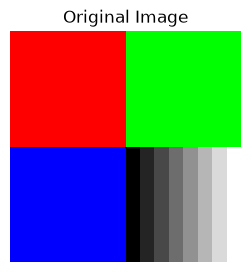

In [64]:
plt.figure(figsize=(3, 3))
plt.imshow(images[0].transpose(1, 2, 0))
plt.axis("off")
plt.title("Original Image")
plt.show()

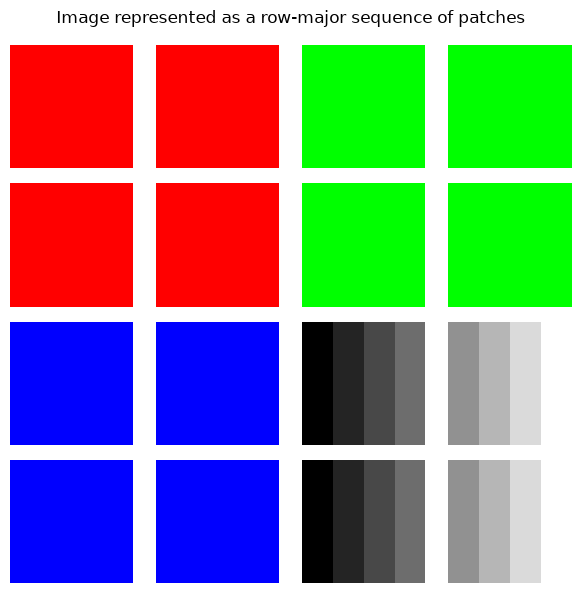

In [69]:
def patches_to_image(patches, image_shape, patch_size):
    """Reconstruct (N, C, H, W) images from flattened patches."""
    channels, height, width = image_shape
    grid_height = height // patch_size
    grid_width = width // patch_size
    # reverse the reshape and transpose performed by image_to_patches.
    images_transposed = patches.reshape(
        -1, grid_height, grid_width, channels, patch_size, patch_size
    )
    images_reshaped = images_transposed.transpose(0, 3, 1, 4, 2, 5)
    images = images_reshaped.reshape(-1, channels, height, width)
    return images


reconstructed = patches_to_image(patches, image.shape, patch_size)
np.testing.assert_array_equal(reconstructed, images)

grid_size = image.shape[1] // patch_size
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
# reshape each flattened patch to (C, P, P), transpose it to
# (P, P, C), and display it in the corresponding grid cell.
for i in range(grid_size):
    for j in range(grid_size):
        patch_index = i * grid_size + j
        patch = patches[0, patch_index].reshape(channels, patch_size, patch_size)
        axes[i, j].imshow(patch.transpose(1, 2, 0))
        axes[i, j].axis("off")
fig.suptitle("Image represented as a row-major sequence of patches")
plt.tight_layout()
plt.show()


## 4. Linear patch projection

Raw patch vectors have width $D_{patch}=CP^2$, which depends on patch size and channel count. A learned affine projection maps every patch into the shared model dimension $D$:

$$
X_{patch}=P_{flat}W_{patch}+b_{patch}.
$$

This is analogous to a learned token embedding, except its input is a continuous pixel vector rather than an integer vocabulary index. The same projection is reused at every patch position.

### Exercise 4 — Project patches to token vectors


In [70]:
model_dim = 12
patch_dim = patches.shape[-1]
W_patch = generator.normal(scale=0.05, size=(patch_dim, model_dim))
b_patch = np.zeros(model_dim)

# apply the shared affine projection to every flattened patch.
patch_tokens = patches @ W_patch + b_patch

assert patch_tokens.shape == (1, 16, model_dim)
np.testing.assert_allclose(patch_tokens[0, 0], patches[0, 0] @ W_patch + b_patch)


## 5. Classification token and positional information

ViT prepends one learned `[CLS]` vector to the patch sequence. Its final encoded representation is used for classification, just as in [Notebook 35](./35_transformer_sequence_classifier.ipynb). With 16 patches:

```text
patch tokens:       (N, 16, D)
broadcast CLS:      (N,  1, D)
combined sequence:  (N, 17, D)
```

Self-attention alone does not know that patch 0 is top-left and patch 15 is bottom-right. Positional representations are therefore added after prepending `[CLS]`, giving position 0 to `[CLS]` and positions 1 through 16 to the patches.

### Exercise 5 — Build the Transformer input sequence


In [73]:
cls_token = generator.normal(scale=0.05, size=(1, 1, model_dim))

# broadcast cls_token across the current batch and prepend it.
batch_cls_token = np.broadcast_to(
    cls_token,
    (patch_tokens.shape[0], 1, model_dim),
)
token_sequence = np.concatenate([batch_cls_token, patch_tokens], axis=1)
# add sinusoidal positional encoding to the complete sequence.
positioned_sequence = add_positional_encoding(token_sequence)

assert token_sequence.shape == (1, 17, model_dim)
assert positioned_sequence.shape == token_sequence.shape
np.testing.assert_allclose(token_sequence[:, 1:], patch_tokens)


## 6. A small ViT forward pass

The patch-token sequence can now enter the same Transformer encoder used for ordinary sequences. The encoder does not intrinsically know whether its tokens came from words, image patches, or another source. The input representation and training objective give those tokens meaning.

After encoding, position 0 is projected to class scores. Attention from the `[CLS]` query to patch keys has 16 values per head; reshaping those values to the $4\times4$ patch grid produces a coarse spatial attention map.

### Exercise 6 — Encode, classify, and map attention to patches


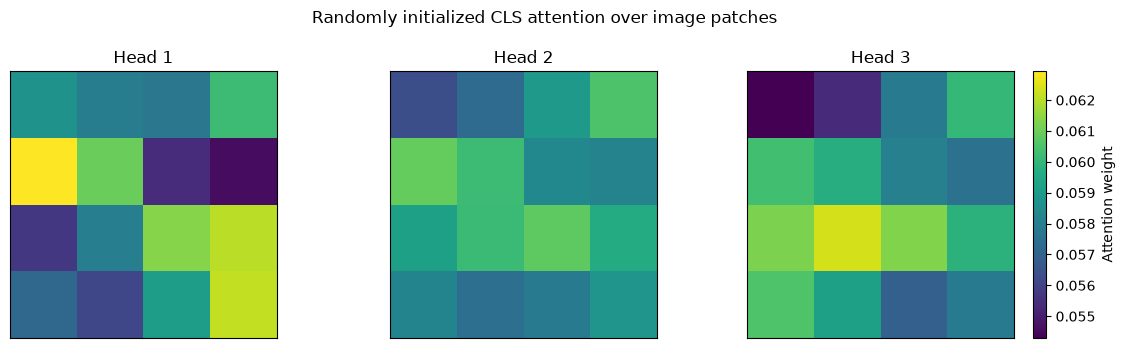

In [84]:
num_heads = 3
feed_forward_dim = 24
num_classes = 4
scale = 0.08
encoder_parameters = {
    "gamma1": np.ones(model_dim),
    "beta1": np.zeros(model_dim),
    "W_query": generator.normal(scale=scale, size=(model_dim, model_dim)),
    "W_key": generator.normal(scale=scale, size=(model_dim, model_dim)),
    "W_value": generator.normal(scale=scale, size=(model_dim, model_dim)),
    "W_output": generator.normal(scale=scale, size=(model_dim, model_dim)),
    "b_query": np.zeros(model_dim),
    "b_key": np.zeros(model_dim),
    "b_value": np.zeros(model_dim),
    "b_output": np.zeros(model_dim),
    "gamma2": np.ones(model_dim),
    "beta2": np.zeros(model_dim),
    "W1": generator.normal(scale=scale, size=(model_dim, feed_forward_dim)),
    "b1": np.zeros(feed_forward_dim),
    "W2": generator.normal(scale=scale, size=(feed_forward_dim, model_dim)),
    "b2": np.zeros(model_dim),
}
W_classifier = generator.normal(scale=scale, size=(model_dim, num_classes))
b_classifier = np.zeros(num_classes)

# run the encoder without a mask: every token is valid.
encoded, attention_weights, _ = transformer_encoder_block_forward(
    positioned_sequence, encoder_parameters, num_heads, mask=None
)
# calculate class scores from encoded position 0.
class_scores = encoded[:, 0] @ W_classifier + b_classifier

assert encoded.shape == positioned_sequence.shape
assert attention_weights.shape == (1, num_heads, 17, 17)
assert class_scores.shape == (1, num_classes)

fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 3.5))
# Exclude key 0 (CLS), then reshape the 16 patch weights to the 4x4 grid.
# display one CLS-to-patch attention map per head with a shared scale.
cls_patch_attention = attention_weights[0, :, 0, 1:]

vmin = cls_patch_attention.min()
vmax = cls_patch_attention.max()

for head, axis in enumerate(axes):
    attention_map = cls_patch_attention[head].reshape(4, 4)
    image_handle = axis.imshow(
        attention_map,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    axis.set_title(f"Head {head + 1}")
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(
    image_handle,
    # ax=axes,
    label="Attention weight",
)
fig.suptitle("Randomly initialized CLS attention over image patches")
plt.tight_layout()
plt.show()


## Reflection

Answer briefly in your own words.

1. How do patch size and image size determine the ViT sequence length?
2. What information is preserved and what structure is temporarily hidden when a patch is flattened?
3. Why is a learned patch projection needed?
4. What is the purpose of `[CLS]` in this image model?
5. Why does a ViT need positional information?
6. What trade-off results from using smaller image patches?
7. Why are the attention maps in Exercise 6 not yet meaningful?

### Answers

1. image is diveded by patches based on its size and patch size and pathes itself are sequence
2. Flattening a patch does not discard its pixel values. It removes their explicit 2D layout from the shape. The projection can still learn from the fixed ordering of those flattened values. The arrangement of different patches across the image is represented through token order and positional encoding.
3. we need to project patch to model dimension and learn patch embeddings
4. gather all the details from all patches throug attention
5. to better understand image structure during learning (where is top-bottom and let-right)
6. better spatial data presentation but more complicated model
7. it is random and not trained
